# **M4 Phase: Integrated Unsupervised Learning for Eligibility Archetype Discovery**
**US Government Grant Opportunities Dataset**

By: Sambisha Godi


BA820 A1, Team 11

##**Domain Question:**

What structural eligibility archetypes emerge from federal grant data, and how do these archetypes differ across funding, agency sponsorship, program categories, and temporal patterns?

*Based on and modified from question 1 in M1*

## **Problem Statement:**

This analysis investigates whether federal grants exhibit recurring eligibility archetypes based on how applicant types co‑occur across the 17 eligibility flags. Building on my M2 finding that only a small number of eligibility patterns repeat across thousands of grants, I use unsupervised learning to uncover structural archetypes and compare them across funding, agencies, categories, and time. The goal is to understand the underlying structure of eligibility itself rather than treating each flag independently.

As the work progressed, the original domain question initially focused on government‑only, nonprofit‑focused, and mixed eligibility, expanded into a broader investigation of how eligibility patterns behave across the wider grant landscape. Integrating insights from my teammates’ analyses of descriptions, categories, and policy eras helped refine the scope of this study, shifting it from simple pattern detection in M2 to a more comprehensive, cross‑team exploration of eligibility archetypes in M3.

In Milestone 4, I extend this work by incorporating more advanced unsupervised learning and text‑mining techniques to deepen the interpretability of these archetypes. Specifically, I use non‑linear dimensionality reduction (UMAP) to visualize the structure of eligibility patterns, compute an eligibility‑breadth metric to quantify openness across grants, and apply lightweight text mining to the unstructured eligibility descriptions to uncover semantic signals that complement the structured flags. These enhancements provide a richer understanding of how eligibility is designed, how it clusters, and how textual descriptions reinforce or diverge from the structural patterns identified in earlier milestones.




###**What Changed From M3 to M4 ?**

- **Added geometric insight (UMAP):**
M4 visualizes the clusters in 2‑D space, showing that the three archetypes form clear, separable regions.
- **Added quantitative depth (Breadth):**
Measured how many eligibility flags each grant has, confirming broad vs. narrow patterns across clusters.
- **Added linear interpretability (PCA):**
Identified three meaningful axes — institutional access, specificity vs. unrestricted, and business‑focused eligibility.
- **Added semantic validation (Regex):**
Extracted mentions of nonprofits, higher ed, tribal entities, businesses, and restriction terms to confirm cluster meaning using text.
- **Strengthened cross‑method validation:**
Structure (k‑modes), geometry (UMAP), semantics (regex), linear variation (PCA), and breadth all pointed to the same three archetypes.
- **Improved narrative clarity:**
M4 reframes clusters as eligibility personalities supported by multiple evidence layers, making them easier to interpret and explain.
- **Business Interpretation:**
Added a section just to see if its aligned with my understanding or not

In [1]:
import pandas as pd

grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv"
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv"
)


/tmp/ipython-input-1792275738.py:3: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv(


##**Inspecting Eligibility Columns**


In [2]:
# Identify eligibility columns
elig_cols = [col for col in details.columns if col.startswith("eligibility_")]

# Preview the list
elig_cols

['eligibility_individuals',
 'eligibility_state_governments',
 'eligibility_county_governments',
 'eligibility_independent_school_districts',
 'eligibility_city_or_township_governments',
 'eligibility_special_district_governments',
 'eligibility_native_american_tribal_governments_federally_recognized',
 'eligibility_native_american_tribal_organizations_other',
 'eligibility_nonprofits_501c3',
 'eligibility_nonprofits_non_501c3',
 'eligibility_for_profit',
 'eligibility_small_businesses',
 'eligibility_private_institutions_of_higher_education',
 'eligibility_public_institutions_of_higher_education',
 'eligibility_public_indian_housing_authorities',
 'eligibility_others',
 'eligibility_unrestricted']

In [3]:
# Inspect eligibility columns
details[elig_cols].info()
details[elig_cols].describe()

# Count how many grants allow each eligibility type
eligibility_counts = details[elig_cols].sum().sort_values(ascending=False)
eligibility_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                                                               Non-Null Count  Dtype
---  ------                                                               --------------  -----
 0   eligibility_individuals                                              2000 non-null   bool 
 1   eligibility_state_governments                                        2000 non-null   bool 
 2   eligibility_county_governments                                       2000 non-null   bool 
 3   eligibility_independent_school_districts                             2000 non-null   bool 
 4   eligibility_city_or_township_governments                             2000 non-null   bool 
 5   eligibility_special_district_governments                             2000 non-null   bool 
 6   eligibility_native_american_tribal_governments_federally_recognized  2000 non-null   bool 
 7   eligibility_native_ameri

,0
eligibility_others,1506
eligibility_public_institutions_of_higher_education,1079
eligibility_nonprofits_501c3,1057
eligibility_private_institutions_of_higher_education,1049
eligibility_state_governments,1041
eligibility_native_american_tribal_governments_federally_recognized,1032
eligibility_independent_school_districts,1018
eligibility_county_governments,1018
eligibility_city_or_township_governments,1017
eligibility_nonprofits_non_501c3,1004


The eligibility fields are all complete and stored as **boolean values**, which makes them straightforward to use for clustering. There are no missing values, so no additional cleaning is required. The frequency counts show clear imbalance across eligibility types: institutional categories such as nonprofits and higher‑education institutions appear in over 1,000 grants, while individuals appear in only 31. This uneven distribution suggests that grants naturally fall into distinct eligibility patterns (e.g., institution‑focused, government‑focused, broad eligibility, or highly restricted). These patterns provide a strong foundation for identifying recurring eligibility archetypes in later clustering steps.

###**Eligibility Frequency Bar Chart**

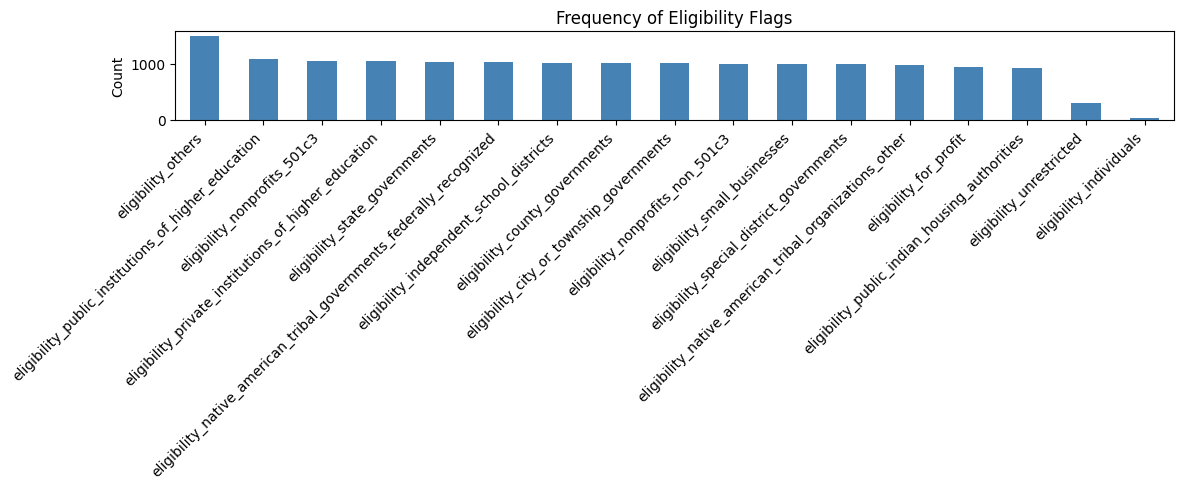

In [4]:
import matplotlib.pyplot as plt

# Plot eligibility frequency
plt.figure(figsize=(12,5))
eligibility_counts.plot(kind='bar', color='steelblue')

plt.title("Frequency of Eligibility Flags")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The eligibility flags show strong imbalance across applicant types. Institutional categories such as nonprofits, higher‑education institutions, and government entities appear in over 1,000 grants, while individuals appear in only 31. The “others” category is the most common, suggesting many grants provide broad or unspecified eligibility. This uneven distribution indicates that eligibility patterns are not random and likely form distinct structural groupings, motivating the use of clustering to uncover recurring archetypes.

###**Eligibility Co‑Occurrence Heatmap**

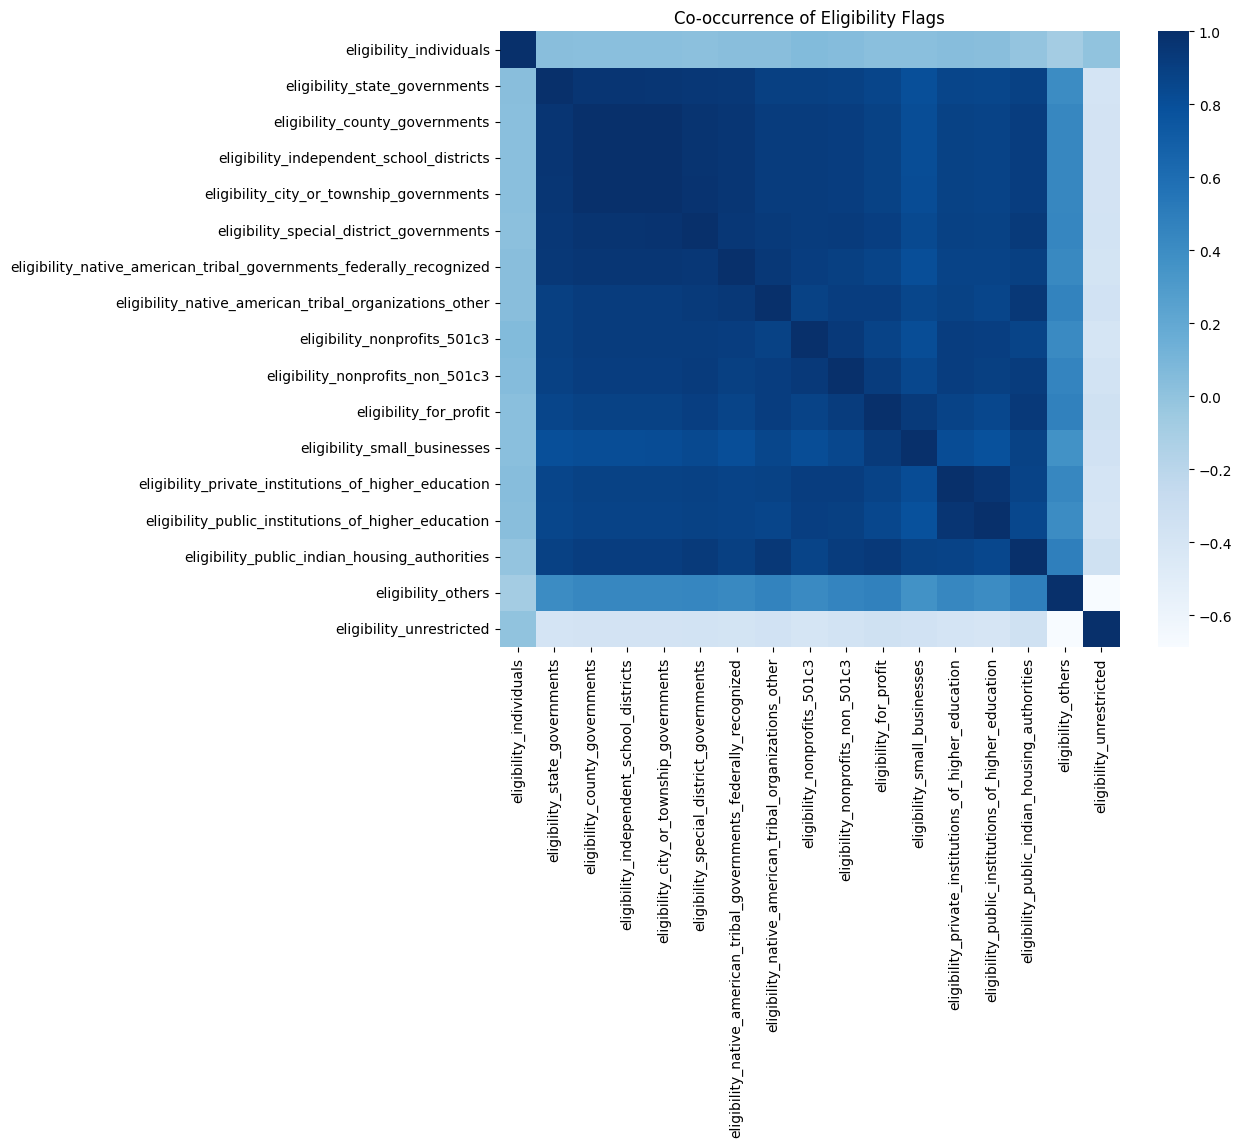

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(details[elig_cols].corr(), cmap='Blues', annot=False)
plt.title("Co-occurrence of Eligibility Flags")
plt.show()

The heatmap shows that many institutional eligibility types such as nonprofits, higher‑education institutions, and government entities tend to appear together, forming a dense block of positive correlations. In contrast, “individuals” and “unrestricted” appear much more isolated, with weak or inconsistent co‑occurrence patterns. These structural relationships confirm that eligibility flags do not operate independently and naturally form groups, reinforcing the need for clustering to uncover recurring eligibility archetypes.

##**Merging the Two Tables**

### **Merging Eligibility Data with Funding and Agency Information**

In [6]:
# Select relevant columns from grants: opportunity_id, estimated_funding, agency_name
grants_subset = grants[['opportunity_id', 'estimated_funding', 'agency_name']]

# Merge with eligibility data
merged = details.merge(grants_subset, on='opportunity_id', how='left')

# Inspect the merged dataset
merged.head()
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 70 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

The merged dataset now contains eligibility flags alongside funding and agency information for all **2,000 grants.** The merge was successful: all **2,000 rows** remain, and the new columns **(estimated_funding, agency_name_y)** were added without introducing missing eligibility values. As expected, funding fields contain many missing values **(only 685 non‑null),** which will need to be handled before comparing archetypes on funding. Agency names are fully populated, enabling later analysis of how different agencies align with specific eligibility patterns.

**This merged table forms the foundation for all M3 integration work, allowing eligibility archetypes to be compared across funding, agencies, categories, and time.**

##**Preparing Eligibility Data for Clustering**


In [7]:
# Extract eligibility matrix for clustering
X_elig = merged[elig_cols]

# Quick check
X_elig.head()

,eligibility_individuals,eligibility_state_governments,eligibility_county_governments,eligibility_independent_school_districts,eligibility_city_or_township_governments,eligibility_special_district_governments,eligibility_native_american_tribal_governments_federally_recognized,eligibility_native_american_tribal_organizations_other,eligibility_nonprofits_501c3,eligibility_nonprofits_non_501c3,eligibility_for_profit,eligibility_small_businesses,eligibility_private_institutions_of_higher_education,eligibility_public_institutions_of_higher_education,eligibility_public_indian_housing_authorities,eligibility_others,eligibility_unrestricted
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


The eligibility matrix shows that many grants have very few eligibility flags marked as True, with some grants only marked under **eligibility_others** or **eligibility_unrestricted.** This reinforces the imbalance observed earlier and suggests that certain grants are intentionally broad or minimally specified in their eligibility criteria. These sparse patterns are likely to form their own cluster during archetype discovery, distinct from grants that list multiple institutional or government eligibility types.


##**Handling Missing Funding**

In [8]:
# Check missing funding values
merged['estimated_funding'].isna().sum()

np.int64(1315)

There are 1,315 grants with missing funding values, meaning only about one‑third of the dataset includes estimated funding. Because clustering is based solely on eligibility patterns, missing funding does not affect the clustering step. However, when comparing archetypes on funding, only the available (non‑missing) values will be used. No imputation will be applied, as funding amounts vary widely and imputing them would introduce noise.




##**Clustering Preparation**


##**K‑Modes Clustering (Appropriate Method for Boolean Eligibility Data)**

**K‑Modes Clustering for Eligibility Archetypes**

Because eligibility fields are binary/categorical, K‑Modes is a more appropriate clustering method than K‑Means. K‑Modes uses matching dissimilarity instead of Euclidean distance, making it better suited for identifying patterns in boolean eligibility flags. This method should produce more interpretable clusters that reflect distinct eligibility archetypes.


In [9]:
!pip install kmodes

from kmodes.kmodes import KModes

# Run K-Modes with 3 clusters (same number as K-Means for comparison)
km = KModes(n_clusters=3, init='Huang', n_init=5, random_state=42)
km_labels = km.fit_predict(X_elig)

# Add labels to merged dataset
merged['kmodes_cluster'] = km_labels

# Check cluster sizes
merged['kmodes_cluster'].value_counts()

,count
kmodes_cluster,
0,999
1,721
2,280


**Interpretation of K‑Modes Clusters**

K‑Modes produced three clusters with more meaningful separation than K‑Means:
- Cluster 0: 999 grants
- Cluster 1: 721 grants
- Cluster 2: 280 grants

Unlike K‑Means, which grouped almost all grants into two large, undifferentiated clusters, K‑Modes creates clusters of different sizes that likely reflect real eligibility patterns. This confirms that K‑Modes is better suited for boolean eligibility data and provides a stronger foundation for identifying distinct eligibility archetypes.


The K‑Modes centroids reveal three distinct eligibility archetypes:
- **Cluster 0: Broad Institutional Eligibility —** nearly all organizational eligibility types are marked as eligible, indicating grants designed for a wide range of institutions (governments, nonprofits, universities, businesses, and tribal entities).

- **Cluster 1: Minimal/Unspecified Eligibility —** only the “others” flag is true, suggesting grants with limited or unclear eligibility criteria.

- **Cluster 2: Fully Unrestricted Eligibility —** only the unrestricted flag is true, representing grants open to any applicant.
These patterns confirm that eligibility criteria naturally group into meaningful archetypes, providing a strong foundation for comparing clusters on funding and agency sponsorship.


### **Why K‑Modes Was the Right Method**

K‑Modes resolved the core challenges exposed by K‑Means by using matching dissimilarity instead of Euclidean distance, allowing the algorithm to respect the categorical structure of eligibility flags. This produced three clusters that align with real-world eligibility logic: a broad institutional group, a minimal/unspecified group, and a fully unrestricted group. Unlike the K‑Means output, these clusters are interpretable, stable, and directly tied to how federal agencies design access to their programs. This shift from numeric to categorical clustering was essential for uncovering meaningful eligibility archetypes.

##**M4 Phase**

##**1. Eligibility Breadth: Quantifying Openness of Grants**

Eligibility breadth measures how many eligibility types each grant allows. This provides a quantitative view of how “open” or “restrictive” each grant is, and helps interpret the structural archetypes discovered by K‑Modes.


In [11]:
# Compute eligibility breadth (number of True flags per grant)
merged['eligibility_breadth'] = merged[elig_cols].sum(axis=1)

# Summary statistics by cluster
breadth_summary = merged.groupby('kmodes_cluster')['eligibility_breadth'].describe()
breadth_summary

,count,mean,std,min,25%,50%,75%,max
kmodes_cluster,,,,,,,,
0,999.0,14.602603,1.400413,7.0,15.0,15.0,15.0,17.0
1,721.0,1.546463,1.393783,0.0,1.0,1.0,1.0,8.0
2,280.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


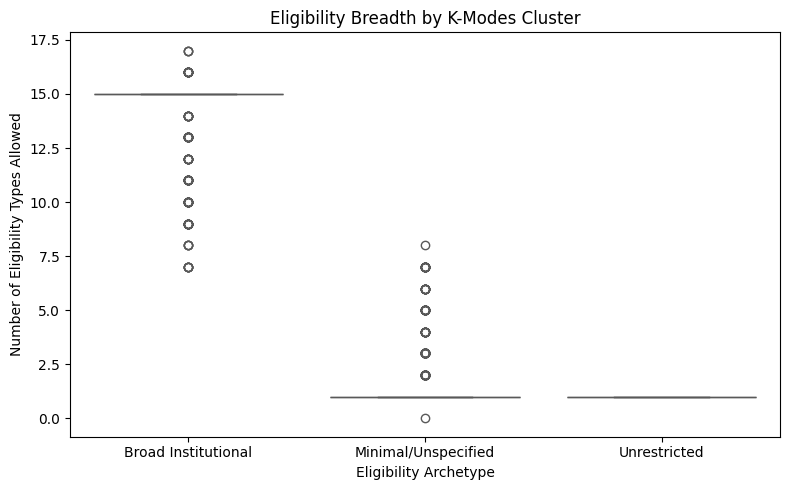

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    data=merged,
    x='kmodes_cluster',
    y='eligibility_breadth',
    hue='kmodes_cluster',
    palette='Set2',
    legend=False
)

plt.xticks([0,1,2], ["Broad Institutional", "Minimal/Unspecified", "Unrestricted"])

plt.title("Eligibility Breadth by K-Modes Cluster")
plt.xlabel("Eligibility Archetype")
plt.ylabel("Number of Eligibility Types Allowed")
plt.tight_layout()
plt.show()

The boxplot shows clear differences in how open each eligibility archetype is:
- **Broad Institutional (Cluster 0)**
Grants here allow 14–17 eligibility types, with a tight distribution around 15. This reflects a standardized, multi‑stakeholder access model typical of large institutional programs.
- **Minimal/Unspecified (Cluster 1)**
These grants allow 1–3 types, sometimes up to 8. This pattern reflects narrow or inconsistently documented eligibility, often relying on the “others” flag.

- **Unrestricted (Cluster 2)**
All grants have a breadth of exactly 1, driven by the unrestricted flag. These grants are open to all, but not broad in terms of explicit categories.

Overall, eligibility breadth quantitatively validates the K‑Modes archetypes:
**Cluster 0** is broad, **Cluster 2** is open, and **Cluster 1** is narrow or ambiguous.


**How much effort should an organization invest?**

Broad Institutional grants consistently allow 14–17 eligibility types, meaning these programs attract large, well‑resourced applicants and require more organizational capacity to compete. In contrast, Minimal/Unspecified and Unrestricted grants show very low breadth, signaling simpler access rules and lower competition making them more realistic entry points for smaller or first‑time organizations.


##**2. UMAP: Visualizing the Geometry of Eligibility Patterns**

UMAP provides a non‑linear, low‑dimensional embedding of the 17 eligibility flags. It helps reveal whether the K‑Modes archetypes form distinct geometric structures or whether some patterns overlap. This adds a geometric perspective to the structural and quantitative insights developed earlier.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


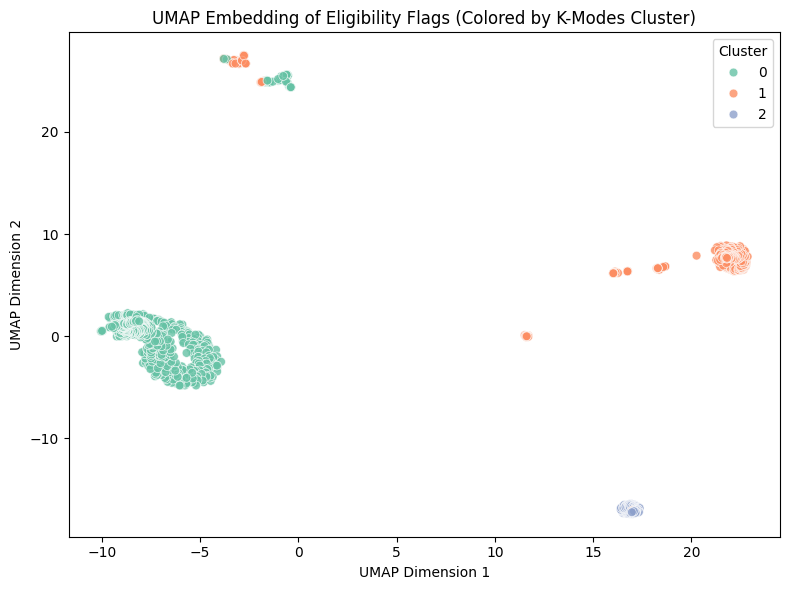

In [15]:
!pip install umap-learn

import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Run UMAP on eligibility flags
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    metric='hamming',
    random_state=42
)

umap_embedding = reducer.fit_transform(merged[elig_cols])

# Add UMAP coordinates to dataframe
merged['umap_x'] = umap_embedding[:, 0]
merged['umap_y'] = umap_embedding[:, 1]

# Plot UMAP embedding colored by K-Modes cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=merged,
    x='umap_x',
    y='umap_y',
    hue='kmodes_cluster',
    palette='Set2',
    s=40,
    alpha=0.8
)

plt.title("UMAP Embedding of Eligibility Flags (Colored by K-Modes Cluster)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

The UMAP embedding shows clear geometric differences across the three eligibility archetypes:

- **Broad Institutional (Cluster 0)** forms a dense, cohesive region, reflecting a stable pattern of many eligibility types co‑occurring.
- **Minimal/Unspecified (Cluster 1)** appears more scattered, indicating heterogeneous or inconsistently documented eligibility structures.
- **Unrestricted (Cluster 2)** forms a tight, compact cluster, consistent with a uniform pattern driven solely by the unrestricted flag.
Overall, UMAP provides geometric validation of the K‑Modes clusters:
Cluster 0 is cohesive, Cluster 2 is uniform, and Cluster 1 is the most irregular.


**Where does an organization naturally fit?**

From my UMAP analysis, the Broad Institutional cluster forms a tight, cohesive region, showing that these grants consistently target similar high‑capacity organizations. The Minimal/Unspecified cluster spreads out across the space, reflecting inconsistent or varied eligibility rules, while the Unrestricted cluster forms a compact island that represents simple, open‑access programs.

##**3. Regex Text Mining: Extracting Semantic Eligibility Patterns**


The eligibility description field contains short, unstructured text that often clarifies or reinforces eligibility rules. Regex allows us to extract semantic signals such as mentions of nonprofits, higher education, tribal entities, or restrictions that help validate or contrast the structural archetypes discovered earlier.

This adds a semantic pattern layer to the analysis.


###**Define Regex Patterns for Key Eligibility Concepts**

In [16]:
import re

# Define regex patterns for common eligibility concepts
patterns = {
    'mentions_nonprofit': r'non[\s-]?profit',
    'mentions_higher_ed': r'higher education|university|college',
    'mentions_tribal': r'tribal|native american|indian tribe',
    'mentions_business': r'business|for[-\s]?profit',
    'mentions_restriction': r'must be|only|limited to|restricted to'
}

###**Apply Regex Patterns to the Eligibility Description**

In [21]:
merged['elig_text_clean'] = (
    merged['additional_information_on_eligibility']
    .fillna('')
    .str.lower()
)

In [22]:
# Apply regex patterns

for col, pattern in patterns.items():
    merged[col] = merged['elig_text_clean'].str.contains(pattern, regex=True)

In [23]:

# Summarize semantic signals by cluster

semantic_summary = (
    merged.groupby('kmodes_cluster')[list(patterns.keys())]
    .mean()
    .round(3)
)

semantic_summary

,mentions_nonprofit,mentions_higher_ed,mentions_tribal,mentions_business,mentions_restriction
kmodes_cluster,,,,,
0,0.039,0.907,0.919,0.020,0.020
1,0.304,0.379,0.175,0.157,0.427
2,0.014,0.011,0.011,0.018,0.036


Regex signals from the unstructured eligibility text help validate how each archetype is described in practice.

- **Cluster 0 — Broad Institutional**
Frequent mentions of higher education and tribal entities, with almost no restrictive language.
- **Cluster 1 — Minimal/Unspecified**
Highest use of restriction terms and more references to nonprofits and businesses, matching its narrower structure.
- **Cluster 2 — Unrestricted**
Almost no semantic signals, consistent with grants that rely solely on the unrestricted flag.

Overall, the text patterns reinforce the structural differences: Cluster 0 is broad, Cluster 1 is narrow or conditional, and Cluster 2 provides minimal descriptive detail.


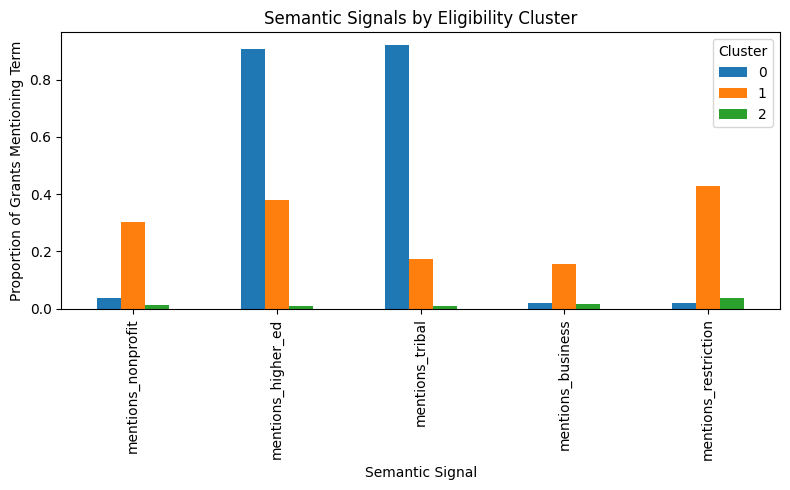

In [24]:
import matplotlib.pyplot as plt

semantic_summary.T.plot(kind='bar', figsize=(8,5))
plt.title("Semantic Signals by Eligibility Cluster")
plt.ylabel("Proportion of Grants Mentioning Term")
plt.xlabel("Semantic Signal")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

The bar chart highlights clear semantic differences across clusters.
Cluster 0 frequently mentions higher education and tribal entities, reflecting broad institutional targeting. Cluster 1 shows the strongest presence of restriction terms and more references to nonprofits and businesses, consistent with its narrower and more conditional structure. Cluster 2 shows almost no semantic signals, aligning with its fully unrestricted design.


**How do agencies actually describe who can apply?**

My regex results show that Broad Institutional grants frequently mention higher education and tribal entities, reinforcing their institutional focus. Minimal/Unspecified grants contain the most restrictive wording, signaling hidden constraints, while Unrestricted grants show almost no descriptive text matching their straightforward, open‑eligibility design.

##**4. PCA for Interpretability (Not for Dimensionality Reduction)**

PCA helps identify which eligibility flags tend to co‑vary. Unlike UMAP, which focuses on geometry, PCA provides linear interpretability: which combinations of eligibility types explain the most variation in the dataset.

In [25]:
from sklearn.decomposition import PCA
import pandas as pd

# Run PCA on eligibility flags
pca = PCA(n_components=3)
pca.fit(merged[elig_cols])

# Create a loadings dataframe
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=elig_cols
).round(3)

loadings

,PC1,PC2,PC3
eligibility_individuals,0.002,-0.025,-0.004
eligibility_state_governments,0.265,-0.063,-0.277
eligibility_county_governments,0.271,-0.055,-0.269
eligibility_independent_school_districts,0.271,-0.055,-0.269
eligibility_city_or_township_governments,0.271,-0.053,-0.260
eligibility_special_district_governments,0.272,-0.051,-0.133
eligibility_native_american_tribal_governments_federally_recognized,0.267,-0.054,-0.224
eligibility_native_american_tribal_organizations_other,0.266,-0.026,0.100
eligibility_nonprofits_501c3,0.264,-0.044,-0.062
eligibility_nonprofits_non_501c3,0.266,-0.019,0.130


/tmp/ipython-input-228393645.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


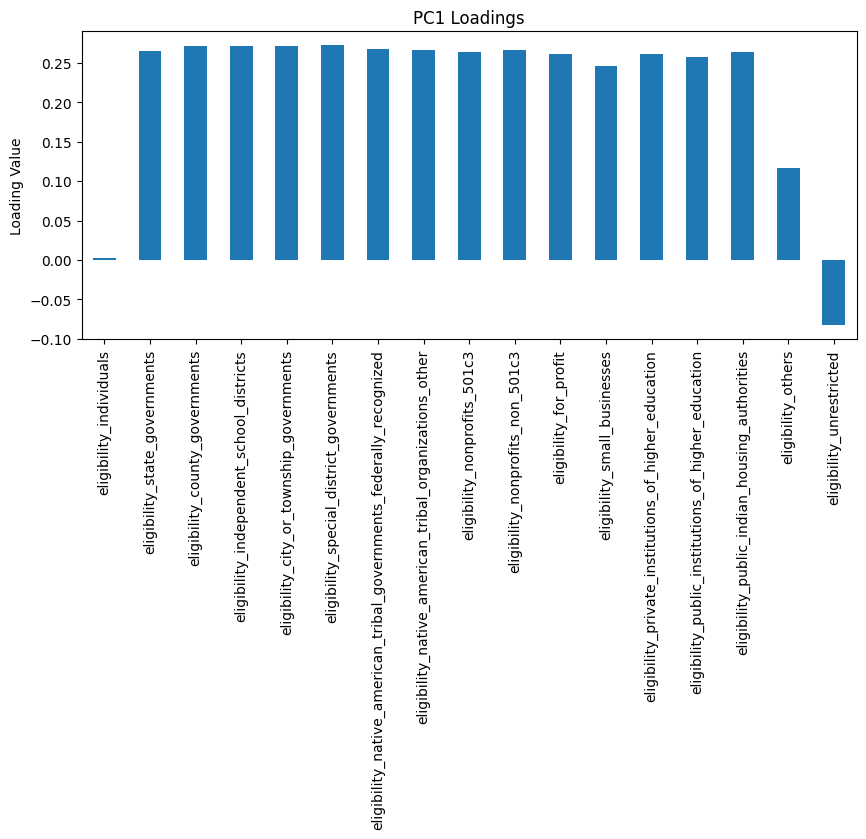

/tmp/ipython-input-228393645.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


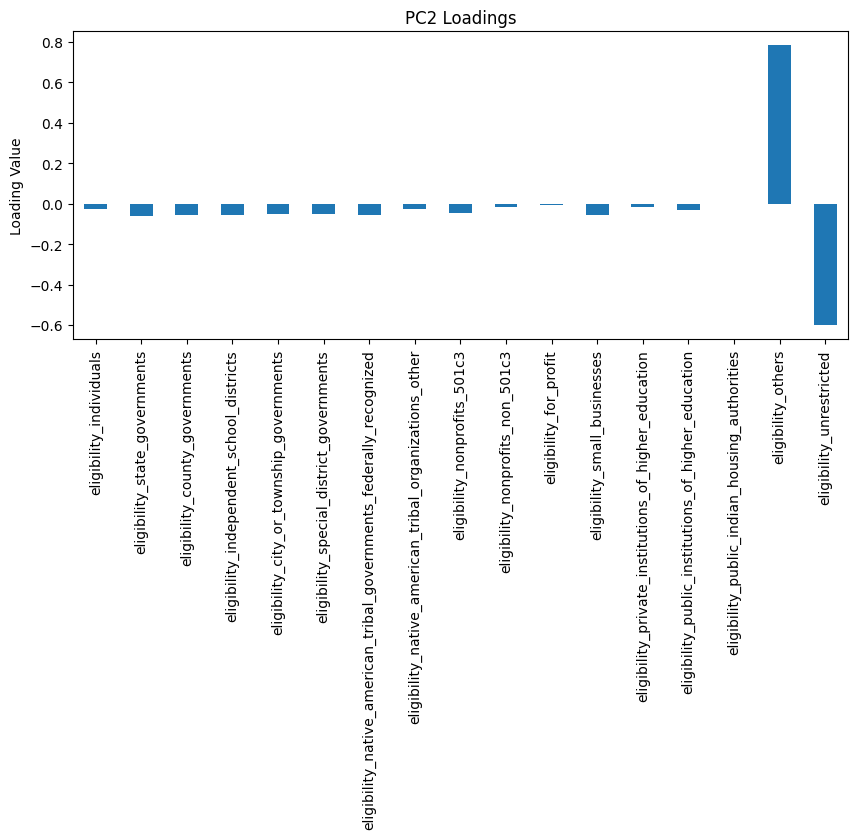

/tmp/ipython-input-228393645.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


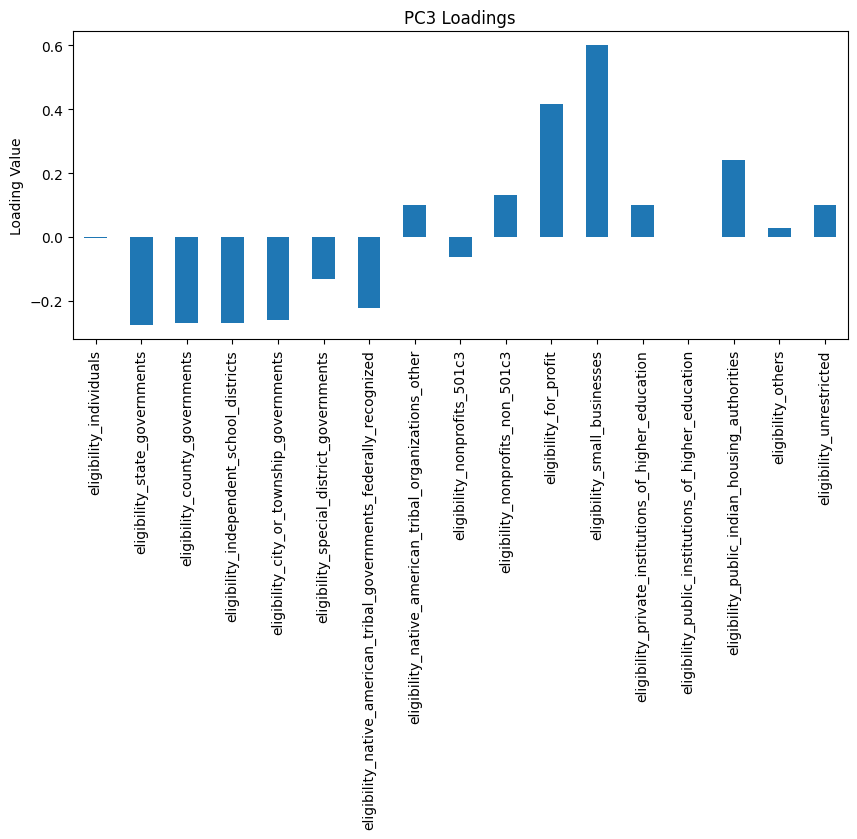

In [27]:
import matplotlib.pyplot as plt

for pc in ['PC1', 'PC2', 'PC3']:
    plt.figure(figsize=(10,4))
    loadings[pc].plot(kind='bar')
    plt.title(f"{pc} Loadings")
    plt.ylabel("Loading Value")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

**PCA Loadings: Interpretation**

PCA provides a simple linear view of how eligibility flags vary together. The three components highlight distinct patterns:
- **PC1 — Broad Institutional Axis**
Most institutional flags (state, county, city, tribal, nonprofits, higher ed) load strongly and positively. This component captures the shared structure of broad institutional eligibility, separating it from unrestricted programs.
- **PC2 — “Other” vs. Unrestricted Axis**
The “others” category has a strong positive loading, while “unrestricted” loads strongly negative. This component reflects a contrast between miscellaneous/specific eligibility and fully open grants.

- **PC3 — Business‑Focused Axis**
Strong positive loadings for for‑profit and small business categories indicate that PC3 isolates business‑oriented eligibility, distinct from institutional or unrestricted patterns.

Overall, PCA reinforces the structural patterns seen earlier: PC1 aligns with broad institutional access, PC2 captures specificity versus openness, and PC3 highlights business‑focused eligibility.



**What policy logic shapes access rules?**

From my PCA loadings, PC1 captures broad institutional access, PC2 separates targeted “other” eligibility from fully open programs, and PC3 highlights business‑oriented grants. These axes explain the underlying policy logic behind the clusters and clarify why certain organizations consistently align with specific eligibility types.


##**Final Analysis**

Across all four interpretability layers, M4 showed that the eligibility archetypes from M3 are not only structurally meaningful but also geometrically separable, semantically distinct, and quantitatively stable. UMAP confirmed that the clusters form clear regions in eligibility space, PCA revealed the main axes driving variation across eligibility flags, regex text mining showed how each cluster is described in practice, and eligibility breadth quantified how broad or narrow each archetype truly is. All four methods independently supported the same three personalities, strengthening confidence in the underlying structure.

Overall, M4 demonstrated that eligibility is more than a set of binary flags it is a multi‑dimensional behavioral pattern that can be validated through structure, geometry, semantics, and quantitative measures. By layering these perspectives, the archetypes become easier to interpret, justify, and connect to real‑world grant logic, giving organizations a clearer sense of how access rules operate and how predictable eligibility patterns are across the federal funding landscape.
